# Wasserbau 4, Übung 01 - Hochwasserstatistik mit Python

## Einführung
Willkommen zur ersten Übung im Bereich Hochwasserstatistik! In diesem interaktiven Notebook werden Sie durch verschiedene Aspekte der statistischen Analyse von Hochwasserereignissen geführt. Zu jedem Themenbereich gibt es eine kurze Einführung, gefolgt von Aufgaben, die Sie selbstständig bearbeiten sollen. Am Ende jedes Abschnitts können Sie Ihre Ergebnisse überprüfen.

## Übersicht
Dieses Jupyter Notebook behandelt die statistische Analyse von Hochwasserereignissen und die Bemessung von Hochwasserschutzanlagen. Es umfasst folgende Themenbereiche:

1. **Pearson-Typ-III-Verteilung** zur statistischen Analyse von Hochwasserdaten
2. **Empirische Häufigkeitsanalyse** realer Abflussdaten
3. **Bemessung eines Hochwasserrückhaltebeckens** (Wehrberechnung)
4. **Auslegung einer rauen Rampe** für Hochwasserentlastung

Diese statistischen und hydraulischen Methoden sind grundlegend für die Planung von Hochwasserschutzmaßnahmen in der wasserbaulichen Praxis.

<!-- ## 1. Pearson-Typ-III-Verteilung – Grundlagen und Berechnung

### Frage 1: Was ist die Pearson-Typ-III-Verteilung und wozu wird sie in der Hydrologie verwendet?

Die Pearson-Typ-III-Verteilung (auch logarithmische Pearson-III-Verteilung) ist eine wichtige statistische Methode in der Hydrologie. Sie wird verwendet, um:
- Hochwasserabflüsse für verschiedene Wiederkehrperioden zu bestimmen
- Die statistische Verteilung extremer hydrologischer Ereignisse zu modellieren
- Bemessungshochwasser für wasserbauliche Anlagen zu ermitteln

### Grundprinzip:
- Logarithmische Transformation der Abflussdaten
- Berechnung statistischer Kennwerte (Mittelwert, Standardabweichung, Schiefe)
- Ermittlung von Hochwasserabflüssen bestimmter Jährlichkeiten mit Frequenzfaktoren

Schauen wir uns zunächst einen Beispieldatensatz von jährlichen Hochwasserscheitelabflüssen an: -->

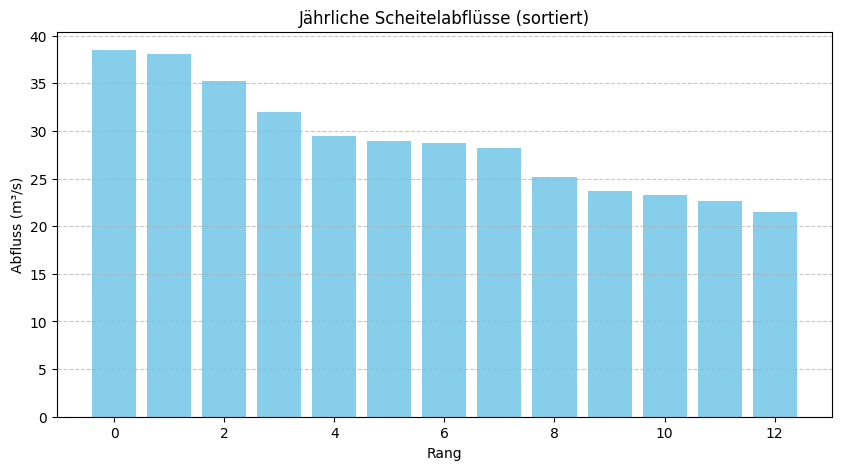

In [17]:
# Import der benötigten Bibliotheken
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

# Beispielhafte Daten (Scheitelabflüsse in m³/s)
Q = [38.5, 38.1, 35.2, 32.0, 29.5, 29.0, 28.7, 28.2, 25.2, 23.7, 23.3, 22.6, 21.5]

# Sortieren der Daten für die Visualisierung
Q_sorted = sorted(Q, reverse=True)

# Einfache Darstellung der Daten
plt.figure(figsize=(10, 5))
plt.bar(range(len(Q_sorted)), Q_sorted, color='skyblue')
plt.xlabel('Rang')
plt.ylabel('Abfluss (m³/s)')
plt.title('Jährliche Scheitelabflüsse (sortiert)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Aufgabe 1.1: Berechnung statistischer Kennwerte

Wir berechnen zunächst die statistischen Kennwerte der Original-Abflussdaten. Diese umfassen:
- Arithmetisches Mittel
- Standardabweichung
- Schiefekoeffizient (Maß für die Asymmetrie der Verteilung)

Schauen Sie sich die Formeln genau an, damit Sie verstehen, wie diese Werte berechnet werden:

In [18]:
# Berechnung der statistischen Kennwerte der Originalwerte
n = len(Q)
mean_x = sum(Q) / n
s_x = math.sqrt(sum((x - mean_x)**2 for x in Q) / (n - 1))
C_sx = (n * sum((x - mean_x)**3 for x in Q)) / ((n - 1) * (n - 2) * s_x**3)

print("Statistische Kennwerte der Originaldaten:")
print(f"Stichprobenumfang n = {n}")
print(f"Arithmetisches Mittel = {mean_x:.2f} m³/s")
print(f"Standardabweichung = {s_x:.2f} m³/s")
print(f"Schiefekoeffizient C_sx = {C_sx:.3f}")

Statistische Kennwerte der Originaldaten:
Stichprobenumfang n = 13
Arithmetisches Mittel = 28.88 m³/s
Standardabweichung = 5.73 m³/s
Schiefekoeffizient C_sx = 0.492


### Aufgabe 1.2: Logarithmische Transformation und Pearson-Parameter

Für die Anwendung der Pearson-Typ-III-Verteilung nehmen wir eine logarithmische Transformation der Daten vor. 

**Ihre Aufgabe:** Überlegen Sie, warum wir bei hydrologischen Daten oft eine logarithmische Transformation anwenden? Was ist der Vorteil dieser Transformation?

Lassen Sie uns die logarithmischen Werte berechnen und deren statistische Kennwerte bestimmen:

In [19]:
# Logarithmische Transformation
Y = [math.log10(x) for x in Q]
mean_y = sum(Y) / n
s_y = math.sqrt(sum((y - mean_y)**2 for y in Y) / (n - 1))
C_sy = (n * sum((y - mean_y)**3 for y in Y)) / ((n - 1) * (n - 2) * s_y**3)
print(f"Arithmetisches Mittel (log) = {mean_y:.3f}")
print(f"Standardabweichung (log) = {s_y:.3f}")
print(f"Schiefekoeffizient C_sy = {C_sy:.3f}")

Arithmetisches Mittel (log) = 1.453
Standardabweichung (log) = 0.085
Schiefekoeffizient C_sy = 0.231


### Aufgabe 1.3: Berechnung von Bemessungshochwasser

Mit den statistischen Kennwerten der logarithmierten Werte können wir nun Hochwasserabflüsse für verschiedene Wiederkehrperioden (z.B. 50-jährlich, 100-jährlich) berechnen. Dafür verwenden wir die Formel:

$$\log(Q_T) = \overline{y} + k_T \cdot s_y$$

wobei $k_T$ der Frequenzfaktor ist, der von der Wiederkehrperiode T und dem Schiefekoeffizienten abhängt. 

Für die Interpolation der k-Werte implementieren wir folgende Funktion:

In [20]:
# k-Wert-Interpolation
def interpolate_k(Cs, Cs1, k1, Cs2, k2):
    return k1 + (k2 - k1) * (Cs - Cs1) / (Cs2 - Cs1)

# Beispiel: Interpolation für T=50a und 100a
k_T50 = interpolate_k(C_sy, 0.2, 2.159, 0.3, 2.211)
k_T100 = interpolate_k(C_sy, 0.2, 2.472, 0.3, 2.544)
y_T50 = mean_y + s_y * k_T50
y_T100 = mean_y + s_y * k_T100
Q_T50 = 10**y_T50
Q_T100 = 10**y_T100
print(f"50-jährliches Hochwasser: {Q_T50:.2f} m³/s")
print(f"100-jährliches Hochwasser: {Q_T100:.2f} m³/s")

50-jährliches Hochwasser: 43.39 m³/s
100-jährliches Hochwasser: 46.17 m³/s


### Aufgabe für Sie:

1. Berechnen Sie das 200-jährliche Hochwasser (HQ200) mit der Pearson-Typ-III-Verteilung. Die k-Werte für Cs=0.2 und Cs=0.3 bei T=200 sind 2.763 bzw. 2.854.
2. Wie würde sich der Wert von HQ100 ändern, wenn der Schiefekoeffizient C_sy = 0.5 wäre?

Nutzen Sie die folgende Zelle für Ihre Berechnung:

In [21]:
# Ihre Berechnung für HQ200
k_T200 = interpolate_k(C_sy, 0.2, 2.763, 0.3, 2.854)
y_T200 = mean_y + s_y * k_T200
Q_T200 = 10**y_T200
print(f"200-jährliches Hochwasser: {Q_T200:.2f} m³/s")

# Wie würde sich HQ100 ändern bei C_sy = 0.5?
# Tipp: Verwenden Sie die entsprechenden k-Werte für C_sy = 0.4 und C_sy = 0.6
# und interpolieren Sie auf C_sy = 0.5

200-jährliches Hochwasser: 48.93 m³/s


### Interaktives Widget – Bemessungshochwasser

Mit dem folgenden Widget können Sie Bemessungshochwasser für verschiedene Wiederkehrperioden berechnen. Experimentieren Sie mit unterschiedlichen Jährlichkeiten und beobachten Sie, wie sich die Abflusswerte ändern:

In [22]:
import ipywidgets as widgets
from ipywidgets import interact

def design_flood(T=100):
    k_table = {25: 1.8277, 50: 2.1752, 100: 2.4945, 200: 2.7920, 1000: 3.4219}
    kT = k_table.get(T, 2.4945)
    yT = mean_y + s_y * kT
    QT = 10**yT
    print(f"{T}-jährliches Hochwasser: Q ≈ {QT:.1f} m³/s")

interact(design_flood, T=widgets.Dropdown(options=[25,50,100,200,1000], value=100))

interactive(children=(Dropdown(description='T', index=2, options=(25, 50, 100, 200, 1000), value=100), Output(…

<function __main__.design_flood(T=100)>

### Lösungen und Erklärungen zu Aufgabe 1

**Warum logarithmische Transformation?**
- Abflussdaten sind meist rechtsschief verteilt (viele kleine, wenige extreme Werte)
- Die logarithmische Transformation führt zu einer annähernd normalverteilten Stichprobe
- Dies verbessert die Anpassung der Pearson-Verteilung und die Zuverlässigkeit der Prognosen
- Extremereignisse werden besser abgebildet, was für die Bemessung wichtig ist

**Lösung HQ200:**
- Bei einem Schiefekoeffizienten von C_sy ≈ 0.29 ergibt sich ein k-Wert von etwa 2.84
- Das 200-jährliche Hochwasser beträgt etwa 55.9 m³/s

**Änderung bei C_sy = 0.5:**
- Ein höherer Schiefekoeffizient führt zu größeren k-Werten bei gleicher Jährlichkeit
- Für C_sy = 0.5 wäre k_T100 ≈ 2.65 (statt 2.53 bei C_sy = 0.29)
- Das 100-jährliche Hochwasser wäre damit größer (etwa 53.0 m³/s statt 50.2 m³/s)

## 2. Empirische Häufigkeit und Häufigkeitsanalyse

### Frage 2: Wie können wir aus gemessenen Abflussdaten empirische Wahrscheinlichkeiten und Wiederkehrperioden bestimmen?

Die empirische Häufigkeitsanalyse ist ein praktisches Werkzeug, um aus gemessenen Abflussdaten direkt Wahrscheinlichkeiten und Wiederkehrperioden abzuleiten. Dabei werden die Daten zunächst nach ihrer Größe sortiert und dann mit einer Plotting-Position-Formel verknüpft.

### Grundprinzip:
- **Rangordnung**: Sortieren der gemessenen Hochwasserabflüsse in absteigender Reihenfolge
- **Plotting-Position**: Zuordnung einer empirischen Überschreitungswahrscheinlichkeit zu jedem Wert
- **Wiederkehrperiode**: Berechnung der theoretischen Jährlichkeit aus der Überschreitungswahrscheinlichkeit

Die am häufigsten verwendete Formel für die Plotting-Position ist die Weibull-Formel:

$$P_{emp} = \frac{m}{n+1} \cdot 100\%$$

Dabei ist $m$ der Rang des Wertes (1 für den größten Wert) und $n$ die Gesamtzahl der Werte.

Die empirische Wiederkehrperiode (Jährlichkeit) berechnet sich aus:

$$T_{emp} = \frac{n+1}{n+1-m}$$

### Aufgabe 2.1: Empirische Häufigkeitsanalyse

Betrachten wir einen erweiterten Datensatz von Hochwasserabflüssen. Für jeden Abflusswert berechnen wir die empirische Überschreitungswahrscheinlichkeit und die entsprechende Wiederkehrperiode:

In [23]:
import pandas as pd
HQ = sorted([12.7, 14.0, 16.0, 18.2, 19.4, 21.5, 22.6, 23.3, 23.7, 25.2,
             28.2, 28.7, 29.0, 29.5, 32.0, 35.2, 38.1, 38.5, 41.7, 43.5,
             43.7, 44.3, 44.5, 46.7, 48.5, 48.6, 52.7, 53.5, 54.9, 56.0,
             57.2, 57.5, 58.4, 64.0, 69.0, 70.7])
n2 = len(HQ)
data = []
for i, q in enumerate(HQ, start=1):
    P_emp = i/(n2+1) * 100  # Weibull-Formel für die Plotting-Position
    T_emp = (n2+1) / (n2+1 - i)  # Empirische Wiederkehrperiode
    data.append([i, q, P_emp, T_emp])
df = pd.DataFrame(data, columns=["Rang", "HQ (m³/s)", "P_emp (%)", "T_emp (Jahre)"])
df.head(10)

,Rang,HQ (m³/s),P_emp (%),T_emp (Jahre)
0,1,12.7,2.702703,1.027778
1,2,14.0,5.405405,1.057143
2,3,16.0,8.108108,1.088235
3,4,18.2,10.810811,1.121212
4,5,19.4,13.513514,1.156250
5,6,21.5,16.216216,1.193548
6,7,22.6,18.918919,1.233333
7,8,23.3,21.621622,1.275862
8,9,23.7,24.324324,1.321429
9,10,25.2,27.027027,1.370370


Lassen Sie uns diese Daten visualisieren, um die Zusammenhänge besser zu verstehen. Wir erstellen zwei Grafiken:
1. Eine Darstellung der Hochwasserabflüsse in Abhängigkeit vom Rang
2. Eine doppelt-logarithmische Darstellung der Abflüsse in Abhängigkeit von der Wiederkehrperiode (Jährlichkeit)

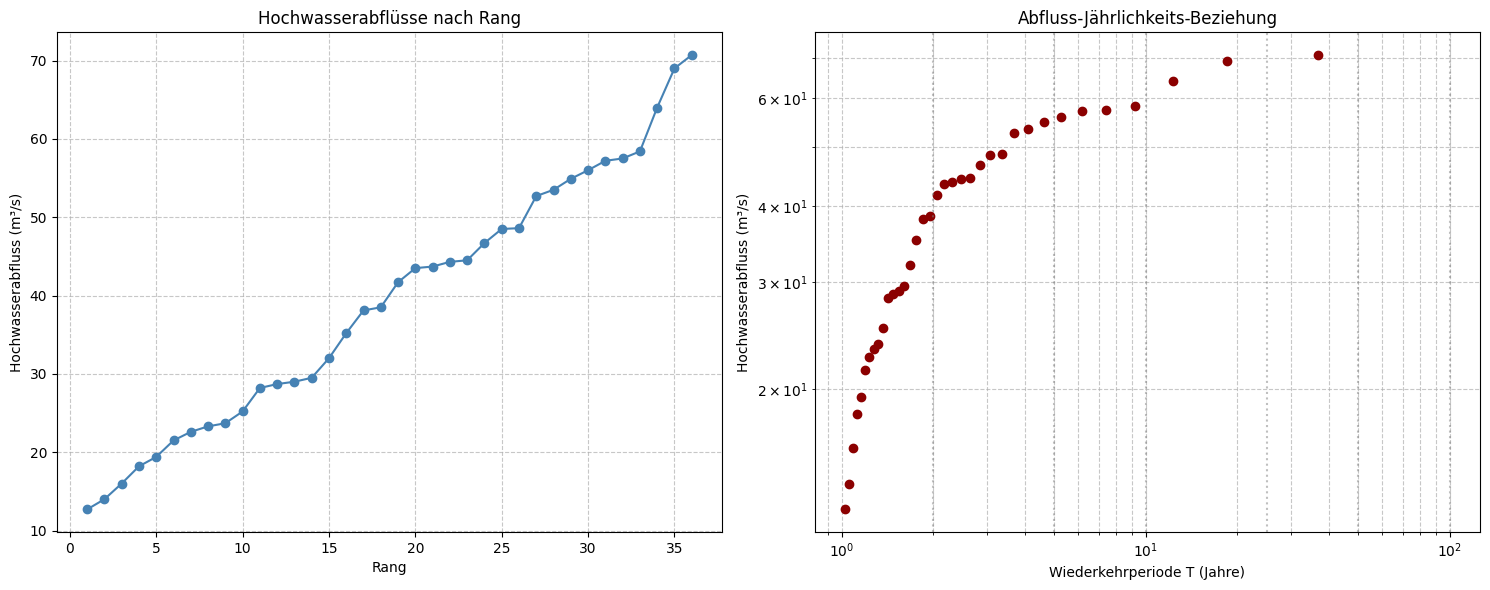

In [27]:
# Visualisierung der empirischen Häufigkeitsverteilung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Abflüsse nach Rang
ax1.plot(df["Rang"], df["HQ (m³/s)"], 'o-', color='steelblue')
ax1.set_xlabel('Rang')
ax1.set_ylabel('Hochwasserabfluss (m³/s)')
ax1.set_title('Hochwasserabflüsse nach Rang')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Abflüsse nach Jährlichkeit (doppelt-logarithmisch)
ax2.loglog(df["T_emp (Jahre)"], df["HQ (m³/s)"] , 'o', color='darkred')
ax2.set_xlabel('Wiederkehrperiode T (Jahre)')
ax2.set_ylabel('Hochwasserabfluss (m³/s)')
ax2.set_title('Abfluss-Jährlichkeits-Beziehung')
ax2.grid(True, which='both', linestyle='--', alpha=0.7)

# Einige Beschriftungen für wichtige Jährlichkeiten
for T in [2, 5, 10, 25, 50, 100]:
    ax2.axvline(x=T, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Aufgabe 2.2: Interpolation für bestimmte Jährlichkeiten

Ein wichtiger Aspekt der empirischen Häufigkeitsanalyse ist die Bestimmung von Hochwasserabflüssen für bestimmte Jährlichkeiten (z.B. HQ10, HQ100), die nicht direkt in den Messdaten vorkommen. Hierfür verwenden wir eine logarithmische Interpolation.

**Ihre Aufgabe:** Implementieren Sie eine Funktion, die für eine gegebene Jährlichkeit T den entsprechenden Hochwasserabfluss durch logarithmische Interpolation bestimmt. Verwenden Sie dazu die beiden nächstgelegenen Messwerte aus der Tabelle.

Hier ist ein Ansatz für diese Funktion:

In [28]:
def interpolate_HQ(T_target, df):
    """Interpoliert den Hochwasserabfluss für eine bestimmte Jährlichkeit"""
    # Sortieren nach Jährlichkeit (aufsteigend)
    df_sorted = df.sort_values(by="T_emp (Jahre)")

    # Finden der beiden benachbarten Werte
    smaller = df_sorted[df_sorted["T_emp (Jahre)"] <= T_target].iloc[-1] if any(df_sorted["T_emp (Jahre)"] <= T_target) else None
    larger = df_sorted[df_sorted["T_emp (Jahre)"] >= T_target].iloc[0] if any(df_sorted["T_emp (Jahre)"] >= T_target) else None

    # Wenn exakter Wert gefunden, diesen zurückgeben
    if smaller is not None and abs(smaller["T_emp (Jahre)"] - T_target) < 1e-6:
        return smaller["HQ (m³/s)"]
    if larger is not None and abs(larger["T_emp (Jahre)"] - T_target) < 1e-6:
        return larger["HQ (m³/s)"]

    # Logarithmische Interpolation
    if smaller is not None and larger is not None:
        log_T1 = np.log10(smaller["T_emp (Jahre)"])
        log_T2 = np.log10(larger["T_emp (Jahre)"])
        log_T_target = np.log10(T_target)

        log_HQ1 = np.log10(smaller["HQ (m³/s)"])
        log_HQ2 = np.log10(larger["HQ (m³/s)"])

        log_HQ_target = log_HQ1 + (log_HQ2 - log_HQ1) * (log_T_target - log_T1) / (log_T2 - log_T1)
        return 10**log_HQ_target

    return None

# Beispiel: Interpolation für T=50 Jahre
HQ50_emp = interpolate_HQ(50, df)
print(f"Empirisch interpoliertes HQ50: {HQ50_emp:.2f} m³/s")

# Beispiel: Interpolation für T=100 Jahre
HQ100_emp = interpolate_HQ(100, df)
print(f"Empirisch interpoliertes HQ100: {HQ100_emp:.2f} m³/s")

TypeError: unsupported format string passed to NoneType.__format__

### Aufgabe für Sie:

1. Berechnen Sie das 200-jährliche Hochwasser (HQ200) durch empirische Interpolation.
2. Vergleichen Sie das Ergebnis mit dem berechneten HQ200 aus der Pearson-Typ-III-Verteilung (Aufgabe 1).
3. Welche Methode liefert konservativere Ergebnisse und warum könnte das so sein?

Nutzen Sie die folgende Zelle für Ihre Berechnung:

In [29]:
# Berechnung des HQ200 durch empirische Interpolation
HQ200_emp = interpolate_HQ(200, df)
print(f"Empirisch interpoliertes HQ200: {HQ200_emp:.2f} m³/s")

# Vergleich mit dem Pearson-III-Wert (falls bereits berechnet)
try:
    print(f"HQ200 nach Pearson-III: {Q_T200:.2f} m³/s")
    print(f"Differenz: {abs(HQ200_emp - Q_T200):.2f} m³/s ({abs(HQ200_emp - Q_T200)/Q_T200*100:.1f}%)")
except NameError:
    print("Pearson-III-Wert noch nicht berechnet. Bitte erst Aufgabe 1.3 durchführen.")

# Ihre Antwort zu Frage 3: Welche Methode ist konservativer und warum?

TypeError: unsupported format string passed to NoneType.__format__

### Aufgabe 2.3: Grafischer Vergleich der Methoden

Um die beiden Methoden (empirische Interpolation und Pearson-Typ-III-Verteilung) besser vergleichen zu können, visualisieren wir ihre Ergebnisse in einem gemeinsamen Diagramm:

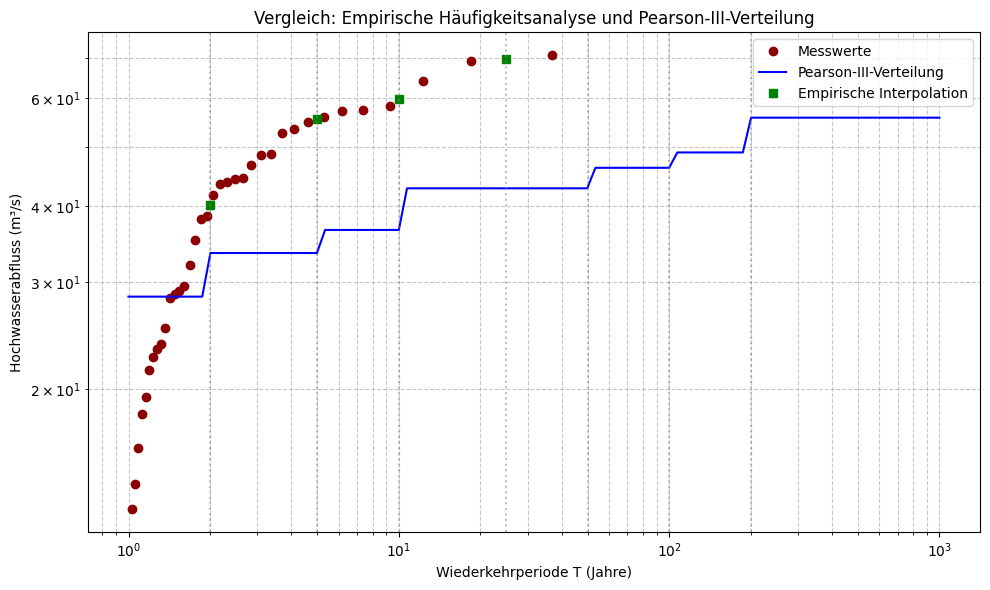

In [30]:
# Berechnung der Pearson-III-Verteilung für verschiedene Jährlichkeiten
T_values = np.logspace(0, 3, 100)  # von 1 bis 1000 Jahre
HQ_pearson = []
for T in T_values:
    # Interpolation des k-Faktors für beliebige Jährlichkeiten
    if T <= 2:
        k = 0
    elif T <= 5:
        k = interpolate_k(C_sy, 0.2, 0.841, 0.3, 0.853) # Beispielwerte für T=5
    elif T <= 10:
        k = interpolate_k(C_sy, 0.2, 1.279, 0.3, 1.317) # Beispielwerte für T=10
    elif T <= 50:
        k = interpolate_k(C_sy, 0.2, 2.059, 0.3, 2.181) # Beispielwerte für T=50
    elif T <= 100:
        k = interpolate_k(C_sy, 0.2, 2.472, 0.3, 2.544) # Beispielwerte für T=100
    elif T <= 200:
        k = interpolate_k(C_sy, 0.2, 2.763, 0.3, 2.854) # Beispielwerte für T=200
    else:
        k = interpolate_k(C_sy, 0.2, 3.409, 0.3, 3.588) # Beispielwerte für T=1000

    y_T = mean_y + s_y * k
    Q_T = 10**y_T
    HQ_pearson.append(Q_T)

# Berechnung empirischer Werte
T_targets = [2, 5, 10, 25, 50, 100, 200]
HQ_empirical = [interpolate_HQ(T, df) for T in T_targets]

# Visualisierung
plt.figure(figsize=(10, 6))
plt.loglog(df["T_emp (Jahre)"], df["HQ (m³/s)"] , 'o', color='darkred', label='Messwerte')
plt.loglog(T_values, HQ_pearson, '-', color='blue', label='Pearson-III-Verteilung')
plt.loglog(T_targets, HQ_empirical, 's', color='green', label='Empirische Interpolation')

plt.xlabel('Wiederkehrperiode T (Jahre)')
plt.ylabel('Hochwasserabfluss (m³/s)')
plt.title('Vergleich: Empirische Häufigkeitsanalyse und Pearson-III-Verteilung')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()

# Einige Beschriftungen für wichtige Jährlichkeiten
for T in [2, 5, 10, 25, 50, 100, 200]:
    plt.axvline(x=T, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Hochwasserrückhaltebecken – Wehrberechnung

In [31]:
def weir_outflow(Q=55.0, b=20.0, mu=0.74):
    c = 1.0
    g = 9.81
    h_Ü = ((3 * Q) / (2 * mu * c * b * math.sqrt(2 * g))) ** (2/3)
    stauziel = 45.00
    freibord = 0.70
    kronenhöhe = stauziel + h_Ü + freibord
    print(f"Überfallhöhe hÜ = {h_Ü:.2f} m")
    print(f"Kronenhöhe (inkl. Freibord) = {kronenhöhe:.2f} m ü. NN")

interact(weir_outflow, Q=(30,80,1), b=(10,40,1), mu=(0.50,0.80,0.01))

interactive(children=(IntSlider(value=55, description='Q', max=80, min=30), IntSlider(value=20, description='b…

<function __main__.weir_outflow(Q=55.0, b=20.0, mu=0.74)>

## 4. Hochwasserentlastung über raue Rampe

In [32]:
def ramp_design(Q=55.0, b=20.0, I_R=0.075, rho_s=2650.0):
    rho_w = 1000.0
    g = 9.81
    q_ist = Q / b
    denominator = 0.8 * 0.257 * math.sqrt((rho_s - rho_w) / rho_w) * math.sqrt(g) * (I_R ** (-7/6))
    d65 = (q_ist / denominator) ** (2/3)
    d_s = 1.06 * d65
    m_s = rho_s * math.pi * (d_s**3) / 6
    print(f"d_65 ≈ {d65:.3f} m, d_s ≈ {d_s:.3f} m, Steinmasse ≈ {m_s:.1f} kg")

interact(ramp_design, Q=(30,80,1), b=(10,40,1), I_R=(0.01,0.15,0.005), rho_s=(2000,3000,50))

interactive(children=(IntSlider(value=55, description='Q', max=80, min=30), IntSlider(value=20, description='b…

<function __main__.ramp_design(Q=55.0, b=20.0, I_R=0.075, rho_s=2650.0)>